<a href="https://colab.research.google.com/github/LiaIssakov/Portfolio_2025/blob/main/Lia_Issakov_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1, Lin. Alg. for Data Science.
# Due date: See discord/canvas.


# Instructions:
-1. Copy the notebook so that you can edit it and save it!

0. Solve the tasks inside the copied notebook (by writing python code and answering extra questions, if any).

1. **Rename the notebook** like this: FirstName_LastName_HW1.ipynb (e.g. I'd rename it as: Hubert_Wagner_HW1.ipynb)

2. Run all the cells in the notebook, so that all results are visible.

3. **Important**: on colab create a shared link using the option **"for anyone with the link"** so that it says "Anyone on the internet with the link can edit". Switch permission to **Editor**.

4. **Submit** the above link on canvas.

5. Later, *when the time comes* answer some brief questions about your solution via a google form I will send you. **This is part of the homework assignment**, so don't miss it!



# Collaboration rules:

**Feel free to collaborate on this (with other live humans). Especially if you're starting out with python/numpy**, it may be valuable to discuss things with someone more experienced. But make sure to write the code on your own, otherwise it's a waste of everyone's time.

The main point of this assignment is for you to practice some skills which are useful for programming related jobs (and are often checked during interviews, including code quality and simple tests).

This also includes some of the annoying things related to files and imports that we otherwise don't need to deal with on colab -- but are crucial to have experience with.


# Tasks Overiew: Approximating hard integrals

> okay, some of them are not so hard.

Implement a python function which can **approximate the value of a definite integral a mathematical function** on an interval $(a,b)$. Use the absolutely simplest possible method that works and **only use the things we covered in class**.

Use your function to evaluate the following definite integrals:
- $$\int_0^{\frac{\pi}{2}} \arccos{\frac{\cos{x}}{1 + 2\cos{x}}}\,dx\, .$$
- $$\int_0^{e} \cosh x dx\, ,$$
- $$\int_1^{e} \frac{1}{x} dx\, ,$$
- $$\int_0^{1} 1 dx\, ,$$
- $$∫_0^1 \log(x-x^2)dx \, ,$$
- $$\int_0^{4\pi} \sin{x}dx \, .$$

Make sure your function does **exectly** what it promises.



# Task 1: Simple python implementation (no numpy) -- sketch

In [13]:
import math # use this for the sketch, later just use numpy

print(math.sin(math.e)) # example usage of a math function

0.41078129050290885


In [3]:
def integrate_sketch   (f,  a,b, n):
    '''
      Approximate the integral of f(x) from a to b using n rectangles.
    '''
    delta_x = (b - a) / n
    result = 0
    for i in range(n):
      result += f(a + i * delta_x) * delta_x
    return result

# Task 2: Simple python implementation (no numpy) -- correct

In [4]:
def integrate (f, a,   b,   n):
    '''
    Approximates the integral of f(x) from a to b using n rectangles
    (midpoint Riemann sum)

    Args:
      f (function): the function to integrate
      a (float): Lower bound of the interval of integration
      b (float): Upper bound of the interval of integration
      n (int): int value for the number of rectangles

    Returns:
      The approximate integral value as a float
    '''
    delta_x = (b - a) / n
    result = 0
    for i in range(n):
      result += f(a + (i + 0.5) * delta_x) * delta_x
    return result

# Task 3: Numpy -- sketch



Write you first sketch of an implementation using numpy -- to the best of your ability without using any help. Don't iterate on this -- leave it as it was before you started fixing/testing/tuning it.

> The point is to honestly identify your current shortcomings and work on them. You'll see that your final product will be much higher quality -- but to see this we need a reference point.

**Whatever you do here will not affect your score**. But I'd be surprised if your solution is the same as the final one after all the subsequent tasks.

In [5]:
import numpy as np

def integrate_numpy_sketch( fun,  aa,   bb, number_of_things):
    '''
    Approximates the integral of f(x) from aa to bb using number_of_things rectangles.
    '''
    delta_x = (bb - aa) / number_of_things
    for i in range(number_of_things):
      result = np.sum(fun(aa + i * delta_x) * delta_x)
    return result

# Task 4: Proper numpy implementation

Work on your implementation, update it to meet requirements from the other
tasks.

In [6]:
%%file to_test.py
import numpy as np
from collections.abc import Callable


def integrate_numpy(fun: Callable, aa: float, bb: float,
                    number_of_things: int):
    ''' Approximates the integral of f(x) from aa to bb using number_of_things
    rectangles using NumPy (midpoint Riemann sum)

    Args:
      fun (Callable): the function to integrate.
      aa (float): Lower bound of the interval of integration
      bb (float): Upper bound of the interval of integration
      number_of_things (int): number of sub-intervals (rectangles) to use
      (must be a positive integer)

    Returns:
      The approximate integral value as a float

    Limitations / Failure Cases:
      - May not produce accurate results if number_of_things is too small for
        some non-linear functions
      - Fails if the function approaches infinity (e.g. 1/x near x=0)
    '''
    delta_x = (bb - aa) / number_of_things
    x = np.linspace(aa + (delta_x / 2), bb - (delta_x / 2), number_of_things)
    result = np.sum(fun(x) * delta_x)
    return result

Writing to_test.py


# Task 5: Tests

**Write and run unit tests** for your implementation (as we did in class using **pytest**).


Hint: the exact values are $\frac{5}{24}\pi^2$, $ \frac{e^e - e^{-e}}{2}$, $1$ and $1$, $-2$ and $0$.)

For each case check if $|res - correct| < 10^{-5}$. You can use the function below.

> Additionally, the  integral of $1$ (example 4)  has to be evaluated correctly using a **small number of 'elements' to approximate**, namely: 1,2, and 3 (using the same function as the others without handling this extra case in a special way). It's essentially meant as an extra test for your algorithm and its implementation, since using many elements may hide some errors.


> Feel free to test on other (mathematical) functions. Try to identify situations in which your function would **not** work! I will ask about this in the feedback form later.


In [7]:
def close_enough(a, b, num_digits):
  return abs(a-b) < 10**-num_digits

In [8]:
# This is an example checking if res=1.000005 is a good enough approximation
# for the correct result (1).
res = 1.000003
assert close_enough(res, 1, num_digits=5) # this 'test' passes

## Important: read why you need the extra function below!

In [9]:
'''IMPORTANT TIP, PLEASE READ! This is useful for one of the examples.
A function taking a vector of values and returning 1 will *not* return a vector,
but rather a single number. This function solves this silly problem,
and you should use it.
'''

def constant_function_of_one(x):
    '''Evaluates a constant function returning 1.
    It handles both a single number and np.array as input.

    Args:
      x: either a float or np.array of length n
    Returns:
      either a single 1. (as a float) or a length-n np.array of 1.
    '''
    return 0 * x + 1.

In [10]:
%%writefile test_integrate_numpy.py
import numpy as np
from to_test import integrate_numpy


def close_enough(a, b, num_digits=5):
    return abs(a - b) < 10 ** -num_digits


def constant_function_of_one(x):
    return 0 * x + 1.0


def arccos_integral(x):
    return np.arccos(np.cos(x) / (1 + 2 * np.cos(x)))


def test_arccos():
    exact = (5 / 24) * (np.pi ** 2)
    approx = integrate_numpy(arccos_integral, 0, np.pi / 2, 10000)
    assert close_enough(approx, exact, num_digits=5)


def test_cosh():
    exact = (np.exp(np.e) - np.exp(-np.e)) / 2
    approx = integrate_numpy(np.cosh, 0, np.e, 10000)
    assert close_enough(approx, exact, num_digits=5)


def one_over_x(x):
    return 1 / x


def test_one_over_x():
    exact = 1.0
    approx = integrate_numpy(one_over_x, 1, np.e, 10000)
    assert close_enough(approx, exact, num_digits=5)


def test_constant_one():
    exact = 1.0
    for n in [1, 2, 3]:
        approx = integrate_numpy(constant_function_of_one, 0, 1, n)
        assert close_enough(approx, exact, num_digits=5)


def log_integral(x):
    return np.log(x - x ** 2)


def test_log():
    exact = -2.0
    approx = integrate_numpy(log_integral, 0, 1, 1000000)
    assert close_enough(approx, exact, num_digits=5)


def test_sin():
    exact = 0.0
    approx = integrate_numpy(np.sin, 0, 4 * np.pi, 10000)
    assert close_enough(approx, exact, num_digits=5)

Overwriting test_integrate_numpy.py


In [11]:
!python -m pytest test_integrate_numpy.py

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: typeguard-4.6.0, anyio-4.15.1, langsmith-0.12.5
collected 6 items                                                              

test_integrate_numpy.py ......                                           [100%]

============================== 6 passed in 0.16s ===============================


# Task 6: Efficiency


Run your 'integrate' functions on the second example (with $\cosh$) using $n = 10^7$ samples. A good implementation using numpy should take around $0.25s = 250ms$. If it's slower go back, re-test, and re-time.

> Remember that mixing numpy and pure python code can lead to slow performance!

Q: How much faster is it than your python (non-numpy) implementation? Measure it.



In [23]:
%%timeit
import math
# the line above will time your code
# your function call goes here
integrate(math.cosh, 0, math.e, 10**7)

1.83 s ± 400 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [24]:
%%timeit
import numpy as np
from to_test import integrate_numpy

integrate_numpy(np.cosh, 0, np.e, 10**7)

197 ms ± 4.25 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [25]:
print(f"The approximate difference in speed between NumPy and Python is {(1.78 / 0.223):.2f} times")

The approximate difference in speed between NumPy and Python is 7.98 times


# Task 7: Documentation

- Make sure your final numpy code that is reusable is properly commented (especially the main function).

- If you've identified any situations in which your function would fail -- mention this in a comment (docstring) so that your users are aware.

- Consider adding **type hints** to your integrate function: https://docs.python.org/3/library/typing.html (it helps the user know what arguments are valid). We haven't discussed this in class, so we can discuss on discord if something is unclear.

- Don't leave unnecessary things in the comments -- someone who calls help on it shoud not be surprised by what they see.



In [26]:
# call 'help' on your function to make sure it's readable for a user
from to_test import integrate_numpy
help(integrate_numpy)

Help on function integrate_numpy in module to_test:

integrate_numpy(
    fun: collections.abc.Callable,
    aa: float,
    bb: float,
    number_of_things: int
)
    Approximates the integral of f(x) from aa to bb using number_of_things rectangles using NumPy
    (midpoint Riemann sum)

    Args:
      fun (Callable): the function to integrate.
      aa (float): Lower bound of the interval of integration
      bb (float): Upper bound of the interval of integration
      number_of_things (int): number of sub-intervals (rectangles) to use (must be a positive integer)

    Returns:
      The approximate integral value as a float

    Limitations / Failure Cases:
      - May not produce accurate results if number_of_things is too small for some non-linear functions
      - Fails if the function approaches infinity (e.g. 1/x near x=0)



# Task 8: Code quality (IMPORTANT!)

In this assigment we'll focus on code quality.

## Python coding standard

Python has a coding standard, namely a specific way python code shoud be formatted etc.

See here: https://peps.python.org/pep-0008/

You don't really need to parse this document, we'll use a tool to analyze our code and tell us what's wrong.

Any professional codebase adhers to a coding standard. Contrary to what many beginners tend to think, it is of **crucial importance**. In the long run unreadable code (as well as untested code) is more of a liability than an asset.

> Do not just use a code formatter. It's important **you** can write decent-looking code, for example for interviews!



## Linter (flake8)
Below we install a special tool (**linter**) which will nitpicks about tiny (and larger) details of your code. It's a standard tool used in any programming-related company.



In [27]:
!pip install flake8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.6 MB/s eta 0:00:00


In [28]:
#

# Run the tool on the files containing:
- your library code
- your tests
- work on them until there are no errors (actually it's impossible to remove one trivial comment)
- keep in mind that if you save the code in a cell into a file by running the cell, the code is not run, it's only saved!

In [77]:
!flake8 *.py

to_test.py:5:57: W291 trailing whitespace
to_test.py:7:79: W291 trailing whitespace
to_test.py:14:74: W291 trailing whitespace
to_test.py:21:78: W291 trailing whitespace


# Task 9: Visualization

Visualize your approach on the "sine" example.

It should show the rectangles exactly as used by your method. Additionally mark the rectangles that contribute positive values in green and the negative ones in red.

> You can use plt.bar. Check the documentation if it has some useful parameters. Use a reasonably small number of elements so that you can use this visualization to explain how your method works. Make sure it's clear that the bars do not overlap.

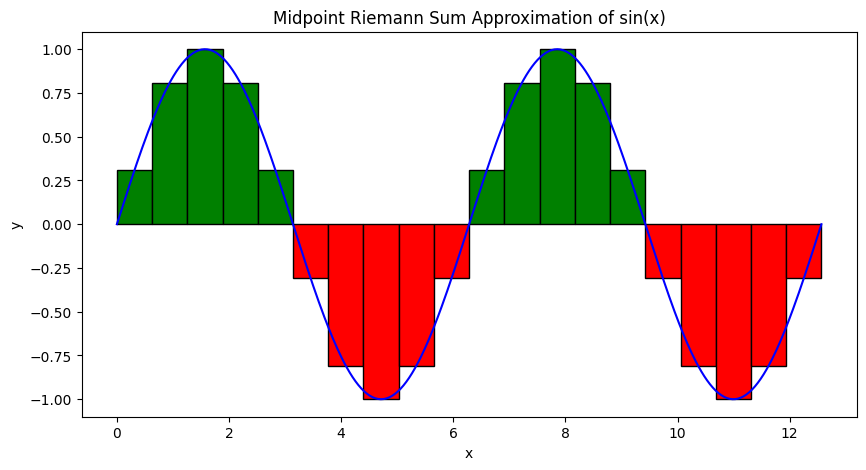

In [28]:
import matplotlib.pyplot as plt

a = 0
b = 4 * np.pi
n = 20
delta_x = (b - a) / n

x_mid = np.linspace(a + delta_x / 2, b - delta_x / 2, n)
y_mid = np.sin(x_mid)

colors = ['green' if y >= 0 else 'red' for y in y_mid]

x_curve = np.linspace(a, b, 500)
y_curve = np.sin(x_curve)

fig, ax = plt.subplots(figsize=(10,5))
plt.bar(x_mid, y_mid, width=delta_x, color=colors, edgecolor = 'black')
plt.plot(x_curve, y_curve, color='blue')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Midpoint Riemann Sum Approximation of sin(x)')

plt.show()

# Evaluation criteria

Later, I will send you a form asking a bunch of question about your solutions.

Some things to look out for:
- correctness
- tests
- code quality (good variable, function names, idiomatic python and numpy usage)
- efficiency (use numpy wisely, avoid python for loops to do heavy computations)
- good comments/documentation (especially for any functions you implement)
- flexibility (there should be only 1 implementation working for any reasonable function-to-be-integrated, no extra cases inside depending on the specific function-to-integrate)
- lack of redundancy (no unnecessary copy-pasting)